<a href="https://colab.research.google.com/github/Parul-gargg/MiniMart_Project/blob/main/MiniMart_Analysis_GitHub_Ready.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MiniMart Sales Analysis — Entry Level Data Analyst Project

**Goal:** Build a small end-to-end analyst project using **Python, SQL and Matplotlib**.

MiniMart is a small retail business operating across four Indian cities. The raw sales data contains duplicates, missing values, inconsistent text, invalid quantities and unusual observations. This project demonstrates how an entry-level data analyst can clean the data, investigate outliers, calculate business metrics, analyse performance and communicate findings.

### Tools
- Python
- Pandas & NumPy
- Matplotlib
- SQLite / SQL

### Project scope
This is intentionally a **small, focused portfolio project**. It covers data cleaning, outlier investigation, revenue/profit analysis, three visualizations and selected SQL queries.

## Workflow

1. Load and inspect the raw data
2. Clean duplicates, text and missing values
3. Validate invalid values
4. Detect and treat outliers using **IQR**
5. Create revenue, cost and profit
6. Answer business questions with Pandas
7. Reproduce selected questions in SQL
8. Create three Matplotlib charts
9. Write an executive summary and recommendations

## Business Questions

- What are the overall revenue, profit, profit margin and average order value?
- Which city performs best in terms of revenue and profit?
- Which product category generates the most revenue and profit?
- Which unusual values need investigation before trusting the analysis?
- Can the cleaned Pandas results be reproduced using SQL?

## 1. Load the Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

pd.set_option("display.max_columns", None)

df = pd.read_csv("data/minimart_sales.csv")
df.head()

Matplotlib is building the font cache; this may take a moment.


,order_id,order_date,product_id,product_name,category,city,quantity,unit_price,cost_price,discount_pct,rating,delivery_minutes,payment_method
0,O0001,2025-04-03,P101,Bread,Grocery,Pune,2,35,22,5,5.0,35.0,UPI
1,O0002,2025-03-05,P101,Bread,Grocery,Bengaluru,3,35,22,15,4.5,27.0,Wallet
2,O0003,2025-02-24,P107,Cooking Oil,Staples,Pune,1,160,118,0,5.0,28.0,Card
3,O0004,2025-03-07,P107,Cooking Oil,Staples,Mumbai,2,160,118,0,3.0,20.0,Cash
4,O0005,2025-04-10,P107,Cooking Oil,Staples,Mumbai,3,160,118,0,4.5,22.0,UPI


## 2. Initial Inspection

The first step is to understand the structure and quality of the raw dataset. We check:
- number of rows and columns
- data types
- missing values
- duplicate rows
- unique values
- numeric summary statistics

In [ ]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nUnique values:")
print(df.nunique())
print("\nNumeric summary:")
df.describe()

Shape: (323, 13)

Missing values:
order_id            0
order_date          0
product_id          0
product_name        0
category            0
city                1
quantity            0
unit_price          0
cost_price          0
discount_pct        0
rating              1
delivery_minutes    1
payment_method      1
dtype: int64

Duplicate rows: 3

Unique values:
order_id            320
order_date          109
product_id            8
product_name          8
category              6
city                  7
quantity              8
unit_price            9
cost_price            8
discount_pct          5
rating                5
delivery_minutes     36
payment_method        4
dtype: int64

Numeric summary:


,quantity,unit_price,cost_price,discount_pct,rating,delivery_minutes
count,323.000000,323.000000,323.000000,323.000000,322.000000,322.000000
mean,2.331269,156.377709,99.733746,9.009288,3.970497,27.925466
std,2.102612,296.524966,92.824504,6.660109,0.676646,11.763798
min,-2.000000,30.000000,18.000000,0.000000,3.000000,12.000000
25%,1.000000,45.000000,25.000000,5.000000,3.500000,22.000000
50%,2.000000,60.000000,42.000000,10.000000,4.000000,27.000000
75%,3.000000,180.000000,120.000000,15.000000,4.500000,33.000000
max,30.000000,5000.000000,320.000000,20.000000,5.000000,180.000000


### Initial data-quality findings

The raw data contains:
- **323 rows and 13 columns**
- **3 exact duplicate rows**
- Missing values in `city`, `rating`, `delivery_minutes` and `payment_method`
- Inconsistent city formatting such as extra spaces and different capitalization
- Invalid quantity values (`0` and `-2`)
- Unusual quantity (`30`)
- Unusual unit price (`₹5,000`)
- Unusual delivery time (`180` minutes)

The important point is that unusual values are investigated before deciding whether to remove them.

## 3. Data Cleaning

### 3.1 Remove exact duplicates

Exact duplicates do not provide additional information, so they are removed.

In [ ]:
df[df.duplicated()][["order_id", "product_name", "city", "quantity", "unit_price"]]

,order_id,product_name,city,quantity,unit_price
320,O0025,Bread,Mumbai,5,35
321,O0088,Rice 5kg,Delhi,1,420
322,O0151,Milk,Mumbai,1,60


In [ ]:
df = df.drop_duplicates().copy()
print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 320


### 3.2 Convert dates and standardize city names

`str.strip()` removes leading/trailing spaces and `str.title()` standardizes capitalization.

`order_date` is converted to a datetime type so it can be used correctly in time-based analysis later.

In [ ]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["city"] = df["city"].str.strip().str.title()

print(df["city"].unique())

['Pune' 'Bengaluru' 'Mumbai' 'Delhi' nan]


### 3.3 Handle missing values

For categorical fields such as `city` and `payment_method`, the missing value is labelled **Unknown** rather than inventing a specific category.

`rating` and `delivery_minutes` are measurement fields. Their missing values are retained as `NaN` because inventing a rating or delivery time could distort later analysis.

In [ ]:
df["city"] = df["city"].fillna("Unknown")
df["payment_method"] = df["payment_method"].fillna("Unknown")

df.isna().sum()

order_id            0
order_date          0
product_id          0
product_name        0
category            0
city                0
quantity            0
unit_price          0
cost_price          0
discount_pct        0
rating              1
delivery_minutes    1
payment_method      0
dtype: int64

### 3.4 Remove impossible quantity values

A quantity of zero or a negative quantity is not a valid sale. These rows are removed.

In [ ]:
print("Quantity values before cleaning:", sorted(df["quantity"].unique()))
df = df[df["quantity"] > 0].copy()
print("Rows after removing invalid quantities:", len(df))

Quantity values before cleaning: [np.int64(-2), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(30)]
Rows after removing invalid quantities: 318


## 4. Outlier Detection — IQR

The **Interquartile Range (IQR)** method helps identify unusually high or low observations.

- Q1 = 25th percentile
- Q3 = 75th percentile
- IQR = Q3 − Q1
- Lower bound = Q1 − 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

An IQR rule **detects** potential outliers; it does not automatically mean that the observation should be deleted. Business context is required.

### 4.1 Quantity

The value `30` is above the IQR upper bound. However, the transaction is otherwise plausible, so it is retained as a possible bulk purchase.

In [ ]:
Q1 = df["quantity"].quantile(0.25)
Q3 = df["quantity"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

df[df["quantity"] > upper_bound][["order_id", "product_name", "quantity", "unit_price"]]

Q1: 1.0
Q3: 3.0
IQR: 2.0
Lower bound: -2.0
Upper bound: 6.0


,order_id,product_name,quantity,unit_price
55,O0056,Biscuits,30,30


### 4.2 Unit price

The IQR calculation flags prices above the upper bound. One transaction has a unit price of **₹5,000** for Biscuits, while the normal price for the same product is ₹30.

This is treated as a data-entry error rather than a genuine high-value sale. Importantly, we do **not** simply filter every price above the IQR bound because that could also remove legitimate observations such as the ₹420 Rice 5kg transaction.

In [ ]:
Q1 = df["unit_price"].quantile(0.25)
Q3 = df["unit_price"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper bound:", upper_bound)

df[df["unit_price"] > upper_bound][["order_id", "product_name", "quantity", "unit_price", "cost_price"]]

Q1: 45.0
Q3: 180.0
IQR: 135.0
Upper bound: 382.5


,order_id,product_name,quantity,unit_price,cost_price
27,O0028,Rice 5kg,4,420,320
41,O0042,Rice 5kg,5,420,320
52,O0053,Rice 5kg,2,420,320
68,O0069,Rice 5kg,1,420,320
82,O0083,Rice 5kg,1,420,320
87,O0088,Rice 5kg,1,420,320
91,O0092,Rice 5kg,3,420,320
93,O0094,Rice 5kg,1,420,320
97,O0098,Rice 5kg,1,420,320
103,O0104,Rice 5kg,2,420,320


In [ ]:
# Remove only the clearly erroneous transaction identified during investigation.
df = df[df["order_id"] != "O0276"].copy()
print("Rows after removing erroneous price record:", len(df))

Rows after removing erroneous price record: 317


### 4.3 Delivery time

The IQR method identifies a **180-minute** delivery. For a quick-commerce business, this is highly unusual. We keep the order itself but replace only the implausible delivery time with `NaN`.

This preserves the order's valid sales information instead of deleting the entire transaction.

In [ ]:
Q1 = df["delivery_minutes"].quantile(0.25)
Q3 = df["delivery_minutes"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper bound:", upper_bound)

df[df["delivery_minutes"] > upper_bound][["order_id", "product_name", "city", "delivery_minutes"]]

Q1: 22.0
Q3: 33.0
IQR: 11.0
Upper bound: 49.5


,order_id,product_name,city,delivery_minutes
165,O0166,Coffee,Mumbai,180.0


In [ ]:
df.loc[df["order_id"] == "O0166", "delivery_minutes"] = np.nan

df[df["order_id"] == "O0166"][
    ["order_id", "delivery_minutes"]
]

,order_id,delivery_minutes
165,O0166,NaN


## 5. Feature Engineering

We create three business measures:

- **Revenue** = quantity × unit price × (1 − discount %)
- **Cost** = quantity × cost price
- **Profit** = revenue − cost

These calculated columns allow us to move from raw transactions to business performance.

In [ ]:
df["revenue"] = df["quantity"] * df["unit_price"] * (1 - df["discount_pct"] / 100)
df["cost"] = df["quantity"] * df["cost_price"]
df["profit"] = df["revenue"] - df["cost"]

df[["quantity", "unit_price", "cost_price", "discount_pct", "revenue", "cost", "profit"]].head(10)

,quantity,unit_price,cost_price,discount_pct,revenue,cost,profit
0,2,35,22,5,66.50,44,22.50
1,3,35,22,15,89.25,66,23.25
2,1,160,118,0,160.00,118,42.00
3,2,160,118,0,320.00,236,84.00
4,3,160,118,0,480.00,354,126.00
5,3,45,28,15,114.75,84,30.75
6,1,180,120,10,162.00,120,42.00
7,5,45,28,5,213.75,140,73.75
8,2,180,120,5,342.00,240,102.00
9,3,180,120,10,486.00,360,126.00


## 6. Python Business Analysis

### Q1. Overall performance

In [ ]:
total_revenue = df["revenue"].sum()
total_profit = df["profit"].sum()
number_of_orders = df["order_id"].nunique()
profit_margin = total_profit / total_revenue * 100
aov = total_revenue / number_of_orders

print(f"Total revenue: ₹{total_revenue:,.0f}")
print(f"Total profit: ₹{total_profit:,.0f}")
print(f"Profit margin: {profit_margin:.2f}%")
print(f"Number of orders: {number_of_orders}")
print(f"Average order value (AOV): ₹{aov:,.2f}")

Total revenue: ₹93,311
Total profit: ₹20,603
Profit margin: 22.08%
Number of orders: 317
Average order value (AOV): ₹294.36


### Q2. Revenue and profit by city

In [ ]:
city_analysis = df.groupby("city")[["revenue", "profit"]].sum()
city_analysis["profit_margin"] = city_analysis["profit"] / city_analysis["revenue"] * 100
city_analysis.round(2)

,revenue,profit,profit_margin
city,,,
Bengaluru,18803.0,4107.0,21.84
Delhi,20885.5,4551.5,21.79
Mumbai,29312.5,7044.5,24.03
Pune,24281.5,4889.5,20.14
Unknown,28.5,10.5,36.84


### Q3. Revenue and profit by category

In [ ]:
category_analysis = df.groupby("category")[["revenue", "profit"]].sum()
category_analysis["profit_margin"] = category_analysis["profit"] / category_analysis["revenue"] * 100
category_analysis.round(2)

,revenue,profit,profit_margin
category,,,
Beverages,20133.0,5133.0,25.50
Dairy,5121.0,1173.0,22.91
Grocery,2695.0,825.0,30.61
Personal Care,21017.0,5137.0,24.44
Snacks,3057.0,1059.0,34.64
Staples,41288.0,7276.0,17.62


### Sanity check: the Snacks anomaly

During the analysis, Snacks initially appeared to have an implausibly high profit margin because of the ₹5,000 Biscuits transaction. Investigating the underlying rows showed that one erroneous record was responsible for most of the apparent profit. After removing that record, Snacks revenue is ₹3,057 and profit is ₹1,059, giving a much more plausible margin of about 34.64%.

This is a useful analyst lesson: **always investigate surprising aggregate results by going back to the underlying transactions.**

In [ ]:
snacks = df[df["category"] == "Snacks"][["revenue", "profit"]].sum()
snacks_profit_margin = snacks["profit"] / snacks["revenue"] * 100
print(f"Snacks revenue: ₹{snacks['revenue']:,.0f}")
print(f"Snacks profit: ₹{snacks['profit']:,.0f}")
print(f"Snacks profit margin: {snacks_profit_margin:.2f}%")

Snacks revenue: ₹3,057
Snacks profit: ₹1,059
Snacks profit margin: 34.64%


## 7. Matplotlib Presentation

The project uses **three focused charts**. Each chart answers a business question rather than simply displaying data.

### Chart 1 — Revenue by Category

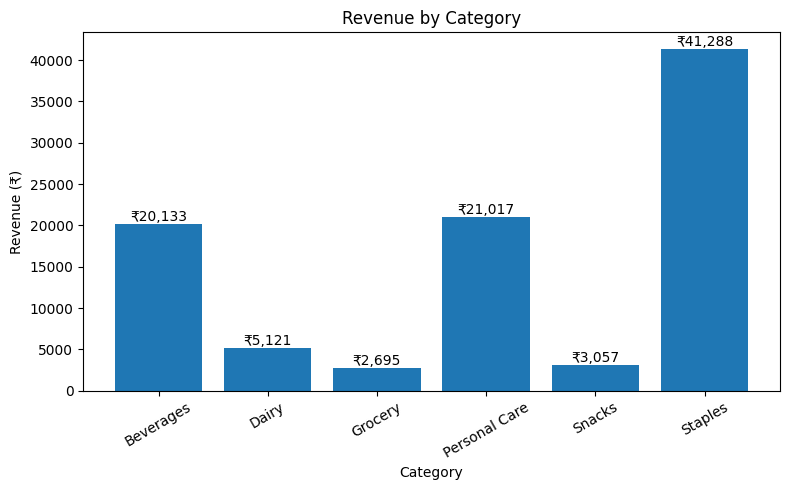

In [ ]:
plt.figure(figsize=(8, 5))
bars = plt.bar(category_analysis.index, category_analysis["revenue"])
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=30)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"₹{bar.get_height():,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

**Interpretation:** Staples generates the highest revenue, followed by Personal Care and Beverages.

### Chart 2 — Profit by Category

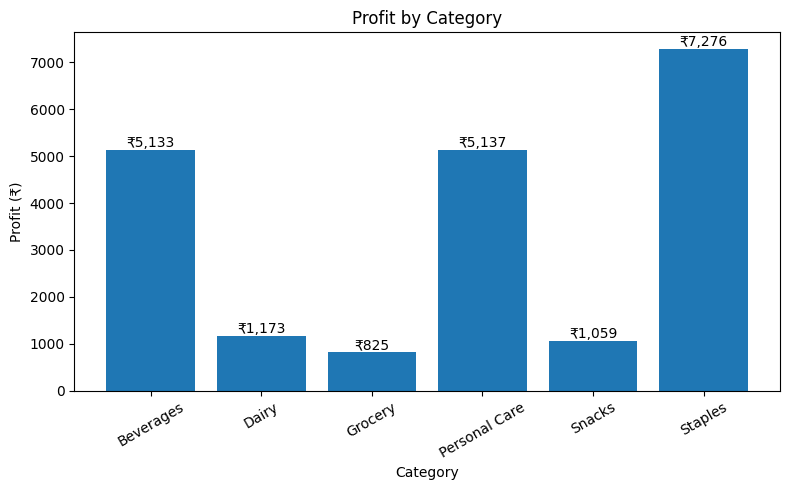

In [ ]:
plt.figure(figsize=(8, 5))
bars = plt.bar(category_analysis.index, category_analysis["profit"])
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit (₹)")
plt.xticks(rotation=30)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"₹{bar.get_height():,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

**Interpretation:** Staples generates the highest absolute profit, although its profit margin is lower than Snacks and Grocery.

### Chart 3 — Revenue vs Profit by City

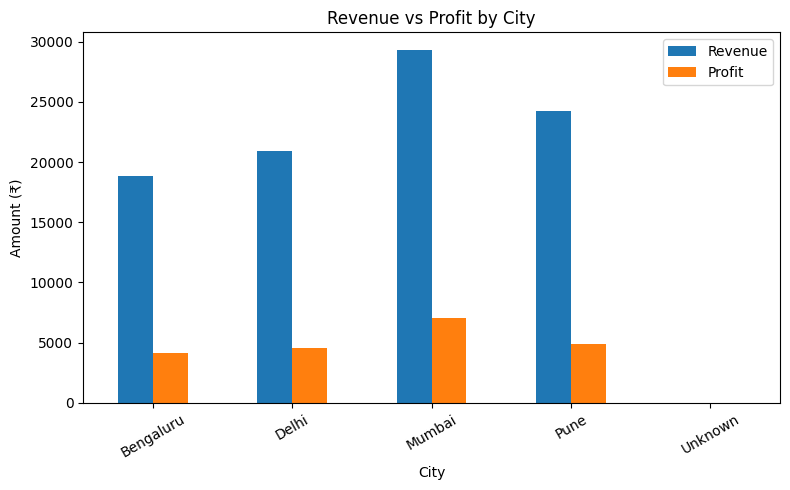

In [ ]:
city_plot = city_analysis[["revenue", "profit"]]
city_plot.plot(kind="bar", figsize=(8, 5))
plt.title("Revenue vs Profit by City")
plt.xlabel("City")
plt.ylabel("Amount (₹)")
plt.xticks(rotation=30)
plt.legend(["Revenue", "Profit"])
plt.tight_layout()
plt.show()

**Interpretation:** Mumbai is the strongest city in both revenue and profit among the main operating cities in this dataset.

## 8. SQL Analysis

The cleaned Pandas DataFrame is loaded into a SQLite table called `orders`. This lets us reproduce business questions using SQL.

`to_sql()` writes the DataFrame to the database. `if_exists="replace"` replaces an existing table, while `index=False` prevents the Pandas index from becoming an unnecessary SQL column.

In [ ]:
conn = sqlite3.connect("minimart.db")
df.to_sql("orders", conn, if_exists="replace", index=False)

pd.read_sql("SELECT * FROM orders LIMIT 5", conn)

,order_id,order_date,product_id,product_name,category,city,quantity,unit_price,cost_price,discount_pct,rating,delivery_minutes,payment_method,revenue,cost,profit
0,O0001,2025-04-03 00:00:00,P101,Bread,Grocery,Pune,2,35,22,5,5.0,35.0,UPI,66.50,44,22.50
1,O0002,2025-03-05 00:00:00,P101,Bread,Grocery,Bengaluru,3,35,22,15,4.5,27.0,Wallet,89.25,66,23.25
2,O0003,2025-02-24 00:00:00,P107,Cooking Oil,Staples,Pune,1,160,118,0,5.0,28.0,Card,160.00,118,42.00
3,O0004,2025-03-07 00:00:00,P107,Cooking Oil,Staples,Mumbai,2,160,118,0,3.0,20.0,Cash,320.00,236,84.00
4,O0005,2025-04-10 00:00:00,P107,Cooking Oil,Staples,Mumbai,3,160,118,0,4.5,22.0,UPI,480.00,354,126.00


### SQL 1 — Filter orders from Mumbai

`WHERE` filters rows before the result is returned.

In [ ]:
pd.read_sql("""
SELECT order_id, product_name, city, revenue, profit
FROM orders
WHERE city = 'Mumbai'
LIMIT 10
""", conn)

,order_id,product_name,city,revenue,profit
0,O0004,Cooking Oil,Mumbai,320.00,84.00
1,O0005,Cooking Oil,Mumbai,480.00,126.00
2,O0008,Soap,Mumbai,213.75,73.75
3,O0013,Coffee,Mumbai,648.00,168.00
4,O0019,Coffee,Mumbai,684.00,204.00
5,O0021,Soap,Mumbai,128.25,44.25
6,O0023,Biscuits,Mumbai,142.50,52.50
7,O0025,Bread,Mumbai,175.00,65.00
8,O0032,Bread,Mumbai,99.75,33.75
9,O0035,Biscuits,Mumbai,27.00,9.00


### SQL 2 — Filter using `AND`

`AND` means **both conditions must be true**.

In [ ]:
pd.read_sql("""
SELECT order_id, product_name, city, revenue, profit
FROM orders
WHERE city = 'Mumbai'
  AND profit > 1000
LIMIT 10
""", conn)

,order_id,product_name,city,revenue,profit


### SQL 3 — Revenue by city

`GROUP BY` creates one result group per city, and `SUM()` adds the revenue within each group.

In [ ]:
pd.read_sql("""
SELECT city,
       COUNT(*) AS total_orders,
       SUM(revenue) AS total_revenue
FROM orders
GROUP BY city
ORDER BY total_revenue DESC
""", conn)

,city,total_orders,total_revenue
0,Mumbai,93,29312.5
1,Pune,77,24281.5
2,Delhi,69,20885.5
3,Bengaluru,77,18803.0
4,Unknown,1,28.5


### SQL 4 — Categories with total revenue above ₹20,000

`HAVING` filters **groups after aggregation**. This is different from `WHERE`, which filters individual rows.

In [ ]:
pd.read_sql("""
SELECT city,
       SUM(revenue) AS total_revenue
FROM orders
GROUP BY city
HAVING SUM(revenue) > 20000
ORDER BY total_revenue DESC
""", conn)

,city,total_revenue
0,Mumbai,29312.5
1,Pune,24281.5
2,Delhi,20885.5


### SQL 5 — Classify orders using `CASE WHEN`

`CASE WHEN` is useful for creating business categories from numeric values.

In [ ]:
pd.read_sql("""
SELECT order_id,
       revenue,
       CASE
           WHEN revenue >= 500 THEN 'High Value'
           ELSE 'Low Value'
       END AS order_value_category
FROM orders
LIMIT 10
""", conn)

,order_id,revenue,order_value_category
0,O0001,66.50,Low Value
1,O0002,89.25,Low Value
2,O0003,160.00,Low Value
3,O0004,320.00,Low Value
4,O0005,480.00,Low Value
5,O0006,114.75,Low Value
6,O0007,162.00,Low Value
7,O0008,213.75,Low Value
8,O0009,342.00,Low Value
9,O0010,486.00,Low Value


### SQL 6 — Count High, Medium and Low Profit orders

In [ ]:
pd.read_sql("""
SELECT
    CASE
        WHEN profit >= 200 THEN 'High Profit'
        WHEN profit >= 100 THEN 'Medium Profit'
        ELSE 'Low Profit'
    END AS profit_category,
    COUNT(*) AS total_orders
FROM orders
GROUP BY profit_category
ORDER BY total_orders DESC
""", conn)

,profit_category,total_orders
0,Low Profit,250
1,Medium Profit,44
2,High Profit,23


### SQL concepts covered

- `SELECT` — chooses the columns or calculations to return
- `FROM` — identifies the table
- `WHERE` — filters rows
- `AND` / `OR` — combine conditions
- `SUM()`, `AVG()`, `COUNT()`, `MAX()`, `MIN()` — aggregate functions
- `GROUP BY` — creates groups for aggregation
- `HAVING` — filters aggregated groups
- `ORDER BY` — sorts results
- `LIMIT` — restricts the number of rows
- `CASE WHEN` — creates conditional categories
- `AS` — creates readable aliases

## 9. Final Executive Summary

- The cleaned dataset contains **317 valid sales transactions** after removing exact duplicates, invalid quantities and one clearly erroneous ₹5,000 Biscuits transaction.
- Total revenue is approximately **₹93,311**, with total profit of approximately **₹20,603** and an overall profit margin of **22.08%**.
- **Staples** generates the highest category revenue (₹41,288) and the highest absolute profit (₹7,276).
- **Mumbai** generates the highest revenue (₹29,313) and highest profit (₹7,045) among the cities in the cleaned dataset.
- Outlier investigation demonstrated why analysts should not automatically delete unusual observations: the quantity of 30 was retained as a plausible bulk purchase, while the ₹5,000 Biscuits price was removed after transaction-level investigation.

## 10. Business Recommendations

1. **Protect the strongest categories.** Staples produces the highest revenue and absolute profit, so management should maintain availability and monitor its pricing and discount strategy.

2. **Use transaction-level validation for unusual values.** The ₹5,000 Biscuits record materially distorted the Snacks results. A pricing validation rule could flag values far outside the normal product price range before they reach reporting.

3. **Use city profitability, not revenue alone, for decisions.** Mumbai leads on both revenue and profit, while city-level margins should be monitored alongside sales volume to ensure growth is profitable.